# 식당주문-연관관계 분석
- order_id:주문번호
- quantity:주문개수
- item_name:음식이름
- choice_description:선택 옵션
- item_price:음식 가격

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [42]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data/chipotle.csv")
data.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98


In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            4622 non-null   int64 
 1   quantity            4622 non-null   int64 
 2   item_name           4622 non-null   object
 3   choice_description  3376 non-null   object
 4   item_price          4622 non-null   object
dtypes: int64(2), object(3)
memory usage: 180.7+ KB


In [44]:
data.describe()

,order_id,quantity
count,4622.000000,4622.000000
mean,927.254868,1.075725
std,528.890796,0.410186
min,1.000000,1.000000
25%,477.250000,1.000000
50%,926.000000,1.000000
75%,1393.000000,1.000000
max,1834.000000,15.000000


In [45]:
print(len(data['order_id'].unique()))
print(len(data['item_name'].unique()))

1834
50


In [46]:
tmp = data['item_name'].unique()
tmp

array(['Chips and Fresh Tomato Salsa', 'Izze', 'Nantucket Nectar',
       'Chips and Tomatillo-Green Chili Salsa', 'Chicken Bowl',
       'Side of Chips', 'Steak Burrito', 'Steak Soft Tacos',
       'Chips and Guacamole', 'Chicken Crispy Tacos',
       'Chicken Soft Tacos', 'Chicken Burrito', 'Canned Soda',
       'Barbacoa Burrito', 'Carnitas Burrito', 'Carnitas Bowl',
       'Bottled Water', 'Chips and Tomatillo Green Chili Salsa',
       'Barbacoa Bowl', 'Chips', 'Chicken Salad Bowl', 'Steak Bowl',
       'Barbacoa Soft Tacos', 'Veggie Burrito', 'Veggie Bowl',
       'Steak Crispy Tacos', 'Chips and Tomatillo Red Chili Salsa',
       'Barbacoa Crispy Tacos', 'Veggie Salad Bowl',
       'Chips and Roasted Chili-Corn Salsa',
       'Chips and Roasted Chili Corn Salsa', 'Carnitas Soft Tacos',
       'Chicken Salad', 'Canned Soft Drink', 'Steak Salad Bowl',
       '6 Pack Soft Drink', 'Chips and Tomatillo-Red Chili Salsa', 'Bowl',
       'Burrito', 'Crispy Tacos', 'Carnitas Crispy Tacos

In [47]:
# Istrip($) : 좌우끝에 특정 문자 제거()
data['item_price'] = data['item_price'].str.lstrip("$").astype(float)
data['item_price']

,item_price
0,2.39
1,3.39
2,3.39
3,2.39
4,16.98
...,...
4617,11.75
4618,11.75
4619,11.25
4620,8.75


In [48]:
chipo_cos = data.groupby('item_name')['item_price'].mean()
chipo_cos.sort_values(ascending=True)

,item_price
item_name,
Canned Soda,1.320577
Canned Soft Drink,1.457641
Side of Chips,1.840594
Bottled Water,1.867654
Chips,2.342844
Chips and Roasted Chili-Corn Salsa,2.390000
Chips and Tomatillo-Green Chili Salsa,2.544194
Chips and Tomatillo-Red Chili Salsa,2.987500
Chips and Mild Fresh Tomato Salsa,3.000000


## 어떤 음식 조합을 제일 선호할까?
1. 음식량 순위 체크 - quantity
2. 주로 먹는 음식 이름 - item_name
3. 음식별 인기있는 선택 옵션 - choice_description

In [49]:
# 필요없는 데이터 삭제
data.drop(['order_id','item_price'],axis='columns',inplace=True)
data

,quantity,item_name,choice_description
0,1,Chips and Fresh Tomato Salsa,NaN
1,1,Izze,[Clementine]
2,1,Nantucket Nectar,[Apple]
3,1,Chips and Tomatillo-Green Chili Salsa,NaN
4,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans..."
...,...,...,...
4617,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ..."
4618,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese..."
4619,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto..."
4620,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu..."


In [50]:
# 추가사항에 아무것도 곁들이지 않은 경우, origin으로 표기

data['choice_description'].fillna('Origin',inplace=True)
data

/tmp/ipython-input-848586381.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['choice_description'].fillna('Origin',inplace=True)


,quantity,item_name,choice_description
0,1,Chips and Fresh Tomato Salsa,Origin
1,1,Izze,[Clementine]
2,1,Nantucket Nectar,[Apple]
3,1,Chips and Tomatillo-Green Chili Salsa,Origin
4,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans..."
...,...,...,...
4617,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ..."
4618,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese..."
4619,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto..."
4620,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu..."


In [51]:
# 대괄호 지우기
# re.sub : 지정한 문자를 제외한 나머지 문자깂들을 전부 지워버리는 함수
# 영어, 쉼표, 공백만 남김

import re
num=0

data['choice_description'] = (data['choice_description'].astype(str)
  .apply(lambda x:re.sub(r'[^a-zA-Z, ]', '',x)))

data

,quantity,item_name,choice_description
0,1,Chips and Fresh Tomato Salsa,Origin
1,1,Izze,Clementine
2,1,Nantucket Nectar,Apple
3,1,Chips and Tomatillo-Green Chili Salsa,Origin
4,2,Chicken Bowl,"TomatilloRed Chili Salsa Hot, Black Beans, Ric..."
...,...,...,...
4617,1,Steak Burrito,"Fresh Tomato Salsa, Rice, Black Beans, Sour Cr..."
4618,1,Steak Burrito,"Fresh Tomato Salsa, Rice, Sour Cream, Cheese, ..."
4619,1,Chicken Salad Bowl,"Fresh Tomato Salsa, Fajita Vegetables, Pinto B..."
4620,1,Chicken Salad Bowl,"Fresh Tomato Salsa, Fajita Vegetables, Lettuce"


In [52]:
# 소스와 재료를 나눠야함
# 현재는[[소스],[재료]], 두개릐 열로 나눠야함

# 공백 정리
data['choice_description'] = data['choice_description'].str.strip()
data.head()

,quantity,item_name,choice_description
0,1,Chips and Fresh Tomato Salsa,Origin
1,1,Izze,Clementine
2,1,Nantucket Nectar,Apple
3,1,Chips and Tomatillo-Green Chili Salsa,Origin
4,2,Chicken Bowl,"TomatilloRed Chili Salsa Hot, Black Beans, Ric..."


In [57]:
# 쉼표를 기준으로 분리해서 리스트화
# for s in x.split(','): 쉼표로 잘린 각 부분을 s로
# if s.strip()!='' : 공백만 있거나 빈문자열이 되면 제외
# 공백이 제거된 항목들만 포함한 리스트로 만들어 준다.
# "A,B,C" -> ["A","B","C"]

data['choice_list'] = data['choice_description'].apply(
    lambda x: [s.strip() for s in x.split(',') if s.strip()!='']
)
# 'choice_description' 첫번째 요소는 source, 나머지는 ingredient
data['source'] = data['choice_list'].apply(
    lambda x:x[0] if len(x) > 0 else None
)
data['ingredient'] = data['choice_list'].apply(
    lambda x:', '.join(x[1:]) if len(x)>1 else None
)

# source가 없는 행은 Origin으로 채우기
# ingredient가 없는 행은 Origin으로 채우기
data['source'] = data['source'].fillna('Origin')
data['ingredient'] = data['ingredient'].fillna('Origin')

# 더이상 이용하지 않을 choice_list 삭제
data = data.drop(columns=['choice_list'])
data

,quantity,item_name,choice_description,source,ingredient
0,1,Chips and Fresh Tomato Salsa,Origin,Origin,Origin
1,1,Izze,Clementine,Clementine,Origin
2,1,Nantucket Nectar,Apple,Apple,Origin
3,1,Chips and Tomatillo-Green Chili Salsa,Origin,Origin,Origin
4,2,Chicken Bowl,"TomatilloRed Chili Salsa Hot, Black Beans, Ric...",TomatilloRed Chili Salsa Hot,"Black Beans, Rice, Cheese, Sour Cream"
...,...,...,...,...,...
4617,1,Steak Burrito,"Fresh Tomato Salsa, Rice, Black Beans, Sour Cr...",Fresh Tomato Salsa,"Rice, Black Beans, Sour Cream, Cheese, Lettuce..."
4618,1,Steak Burrito,"Fresh Tomato Salsa, Rice, Sour Cream, Cheese, ...",Fresh Tomato Salsa,"Rice, Sour Cream, Cheese, Lettuce, Guacamole"
4619,1,Chicken Salad Bowl,"Fresh Tomato Salsa, Fajita Vegetables, Pinto B...",Fresh Tomato Salsa,"Fajita Vegetables, Pinto Beans, Guacamole, Let..."
4620,1,Chicken Salad Bowl,"Fresh Tomato Salsa, Fajita Vegetables, Lettuce",Fresh Tomato Salsa,"Fajita Vegetables, Lettuce"


In [58]:
# item_name별 판매수량 합계

item_summary = data.groupby('item_name')['quantity'].sum().reset_index()
item_summary = item_summary.sort_values('quantity',ascending=False)
item_summary.head()

,item_name,quantity
17,Chicken Bowl,761
18,Chicken Burrito,591
25,Chips and Guacamole,506
39,Steak Burrito,386
10,Canned Soft Drink,351


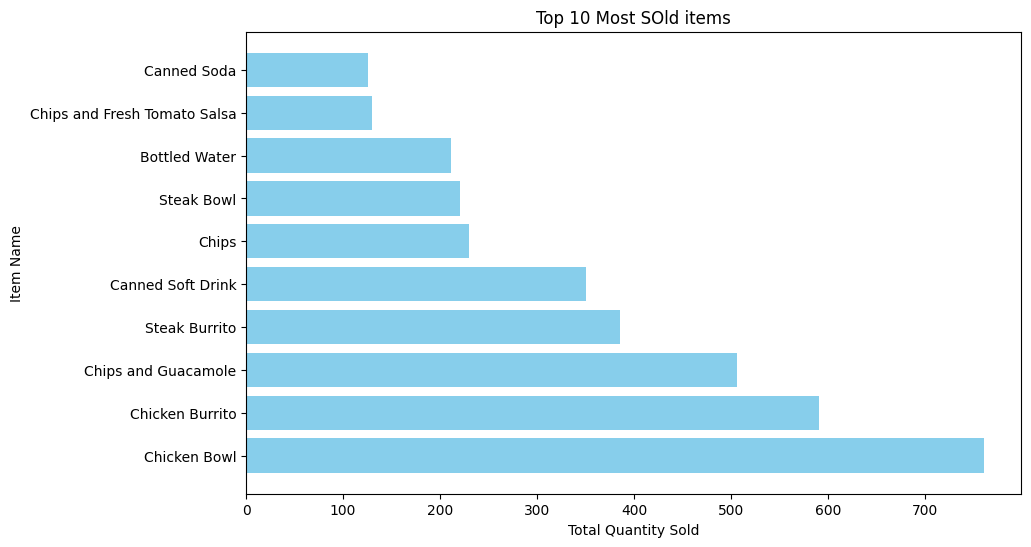

In [59]:
top10 = item_summary.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["item_name"],top10['quantity'],color='skyblue')
plt.title('Top 10 Most SOld items')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Item Name')
plt.show()